In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import lalsimulation as lalsim
import h5py
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
from pycbc import conversions, waveform
from pycbc.waveform import get_fd_waveform, get_td_waveform
from matplotlib import rc
from matplotlib import colormaps
import matplotlib as mpl
import matplotlib.patches as mpatches
import time 
import os
from tqdm import tqdm
from pycbc.waveform.bank import PhenomXPTemplate, compute_beta
path_to_custom_latex_bin = '/home/rahul.dhurkunde/envs/pycbc-test/latex/bin/x86_64-linux'

# Add this to the system PATH environment variable
os.environ["PATH"] += os.pathsep + path_to_custom_latex_bin

# Verify it's working by asking the system to find latex
print("Latex location:", os.popen("which latex").read().strip())


mpl.rcParams['figure.figsize'] = [7.0, 7.0]
plt.rcParams['figure.dpi'] = 300
mpl.rcParams['font.size'] = 13

rc('font', family='serif', weight = 'bold')
rc('text', usetex=True)

class template_params:
    def __init__(self, bank, x):
        for key in bank.keys():
            setattr(self, key, bank[key][x])

Latex location: /home/rahul.dhurkunde/envs/pycbc-test/latex/bin/x86_64-linux/latex


## Mismatch = 0.97 Bank

In [2]:
t = h5py.File('/home/rahul.dhurkunde/searches/BBH-precession/Bank/prec-full-bank.h5')

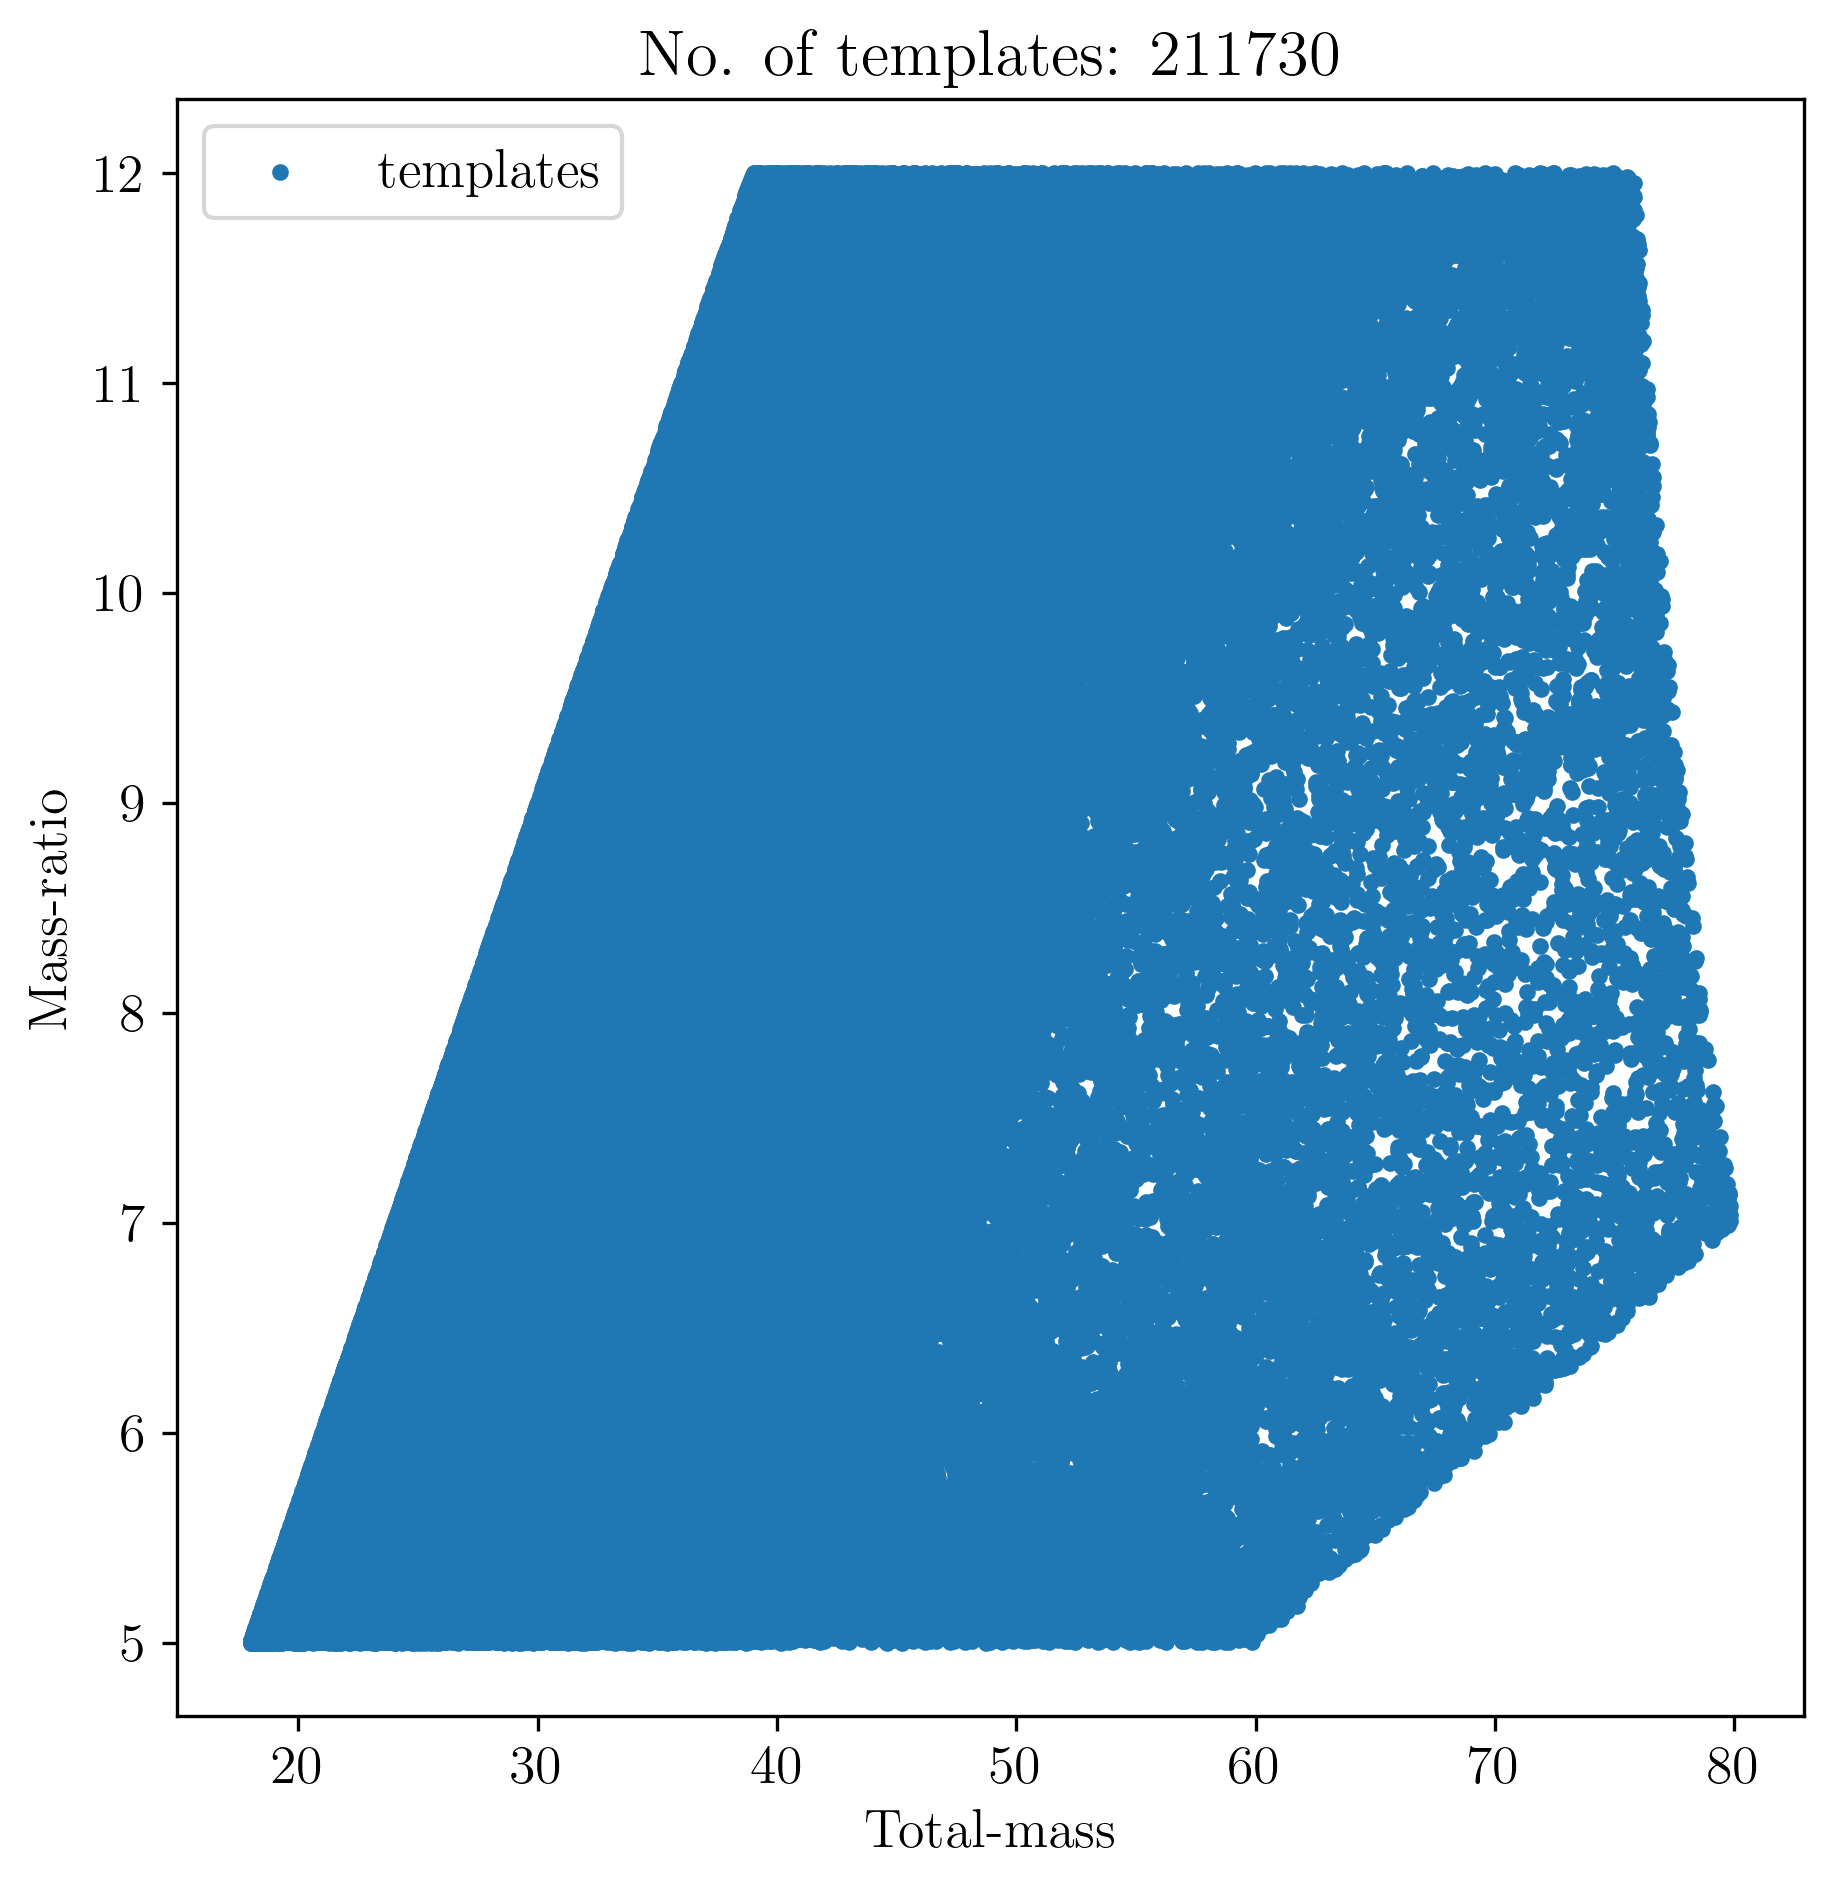

In [3]:
plt.scatter((t['mass1'][:]+t['mass2'][:]), t['mass1'][:]/t['mass2'][:], marker='.', label='templates')

plt.xlabel('Total-mass')
plt.ylabel('Mass-ratio')
title1 = 'No. of templates: {}'.format(len(t['mass1'][:]))

plt.title(title1)
plt.legend()
plt.show()

In [5]:
#highmatch = h5py.File('..//PRODUCTION/PRECESSION/BANKSIM/reverse-harm-run-prod/broadinj1match/H1L1-BANKSIM_MATCH_COMBINE_BROADINJ1-2620801-1163865616.h5')
highmatch = h5py.File('/home/rahul.dhurkunde/searches/BBH-precession/PRODUCTION/PRECESSION/BANKSIM/final-run-prod//broadinj1match/H1L1-BANKSIM_MATCH_COMBINE_BROADINJ1-2620801-1163865616.h5')

#shaved_match = h5py.File('../PRODUCTION/PRECESSION/BANKSIM/reverse-harm-run-temp/broadinj1match/H1L1-BANKSIM_MATCH_COMBINE_BROADINJ1-2620801-1163865616.h5')
shaved_match = h5py.File('/home/rahul.dhurkunde/searches/BBH-precession/PRODUCTION/PRECESSION/BANKSIM/final-run-prod-og-harm/broadinj1match/H1L1-BANKSIM_MATCH_COMBINE_BROADINJ1-2620801-1163865616.h5')

## Fitting-factor CDF for  

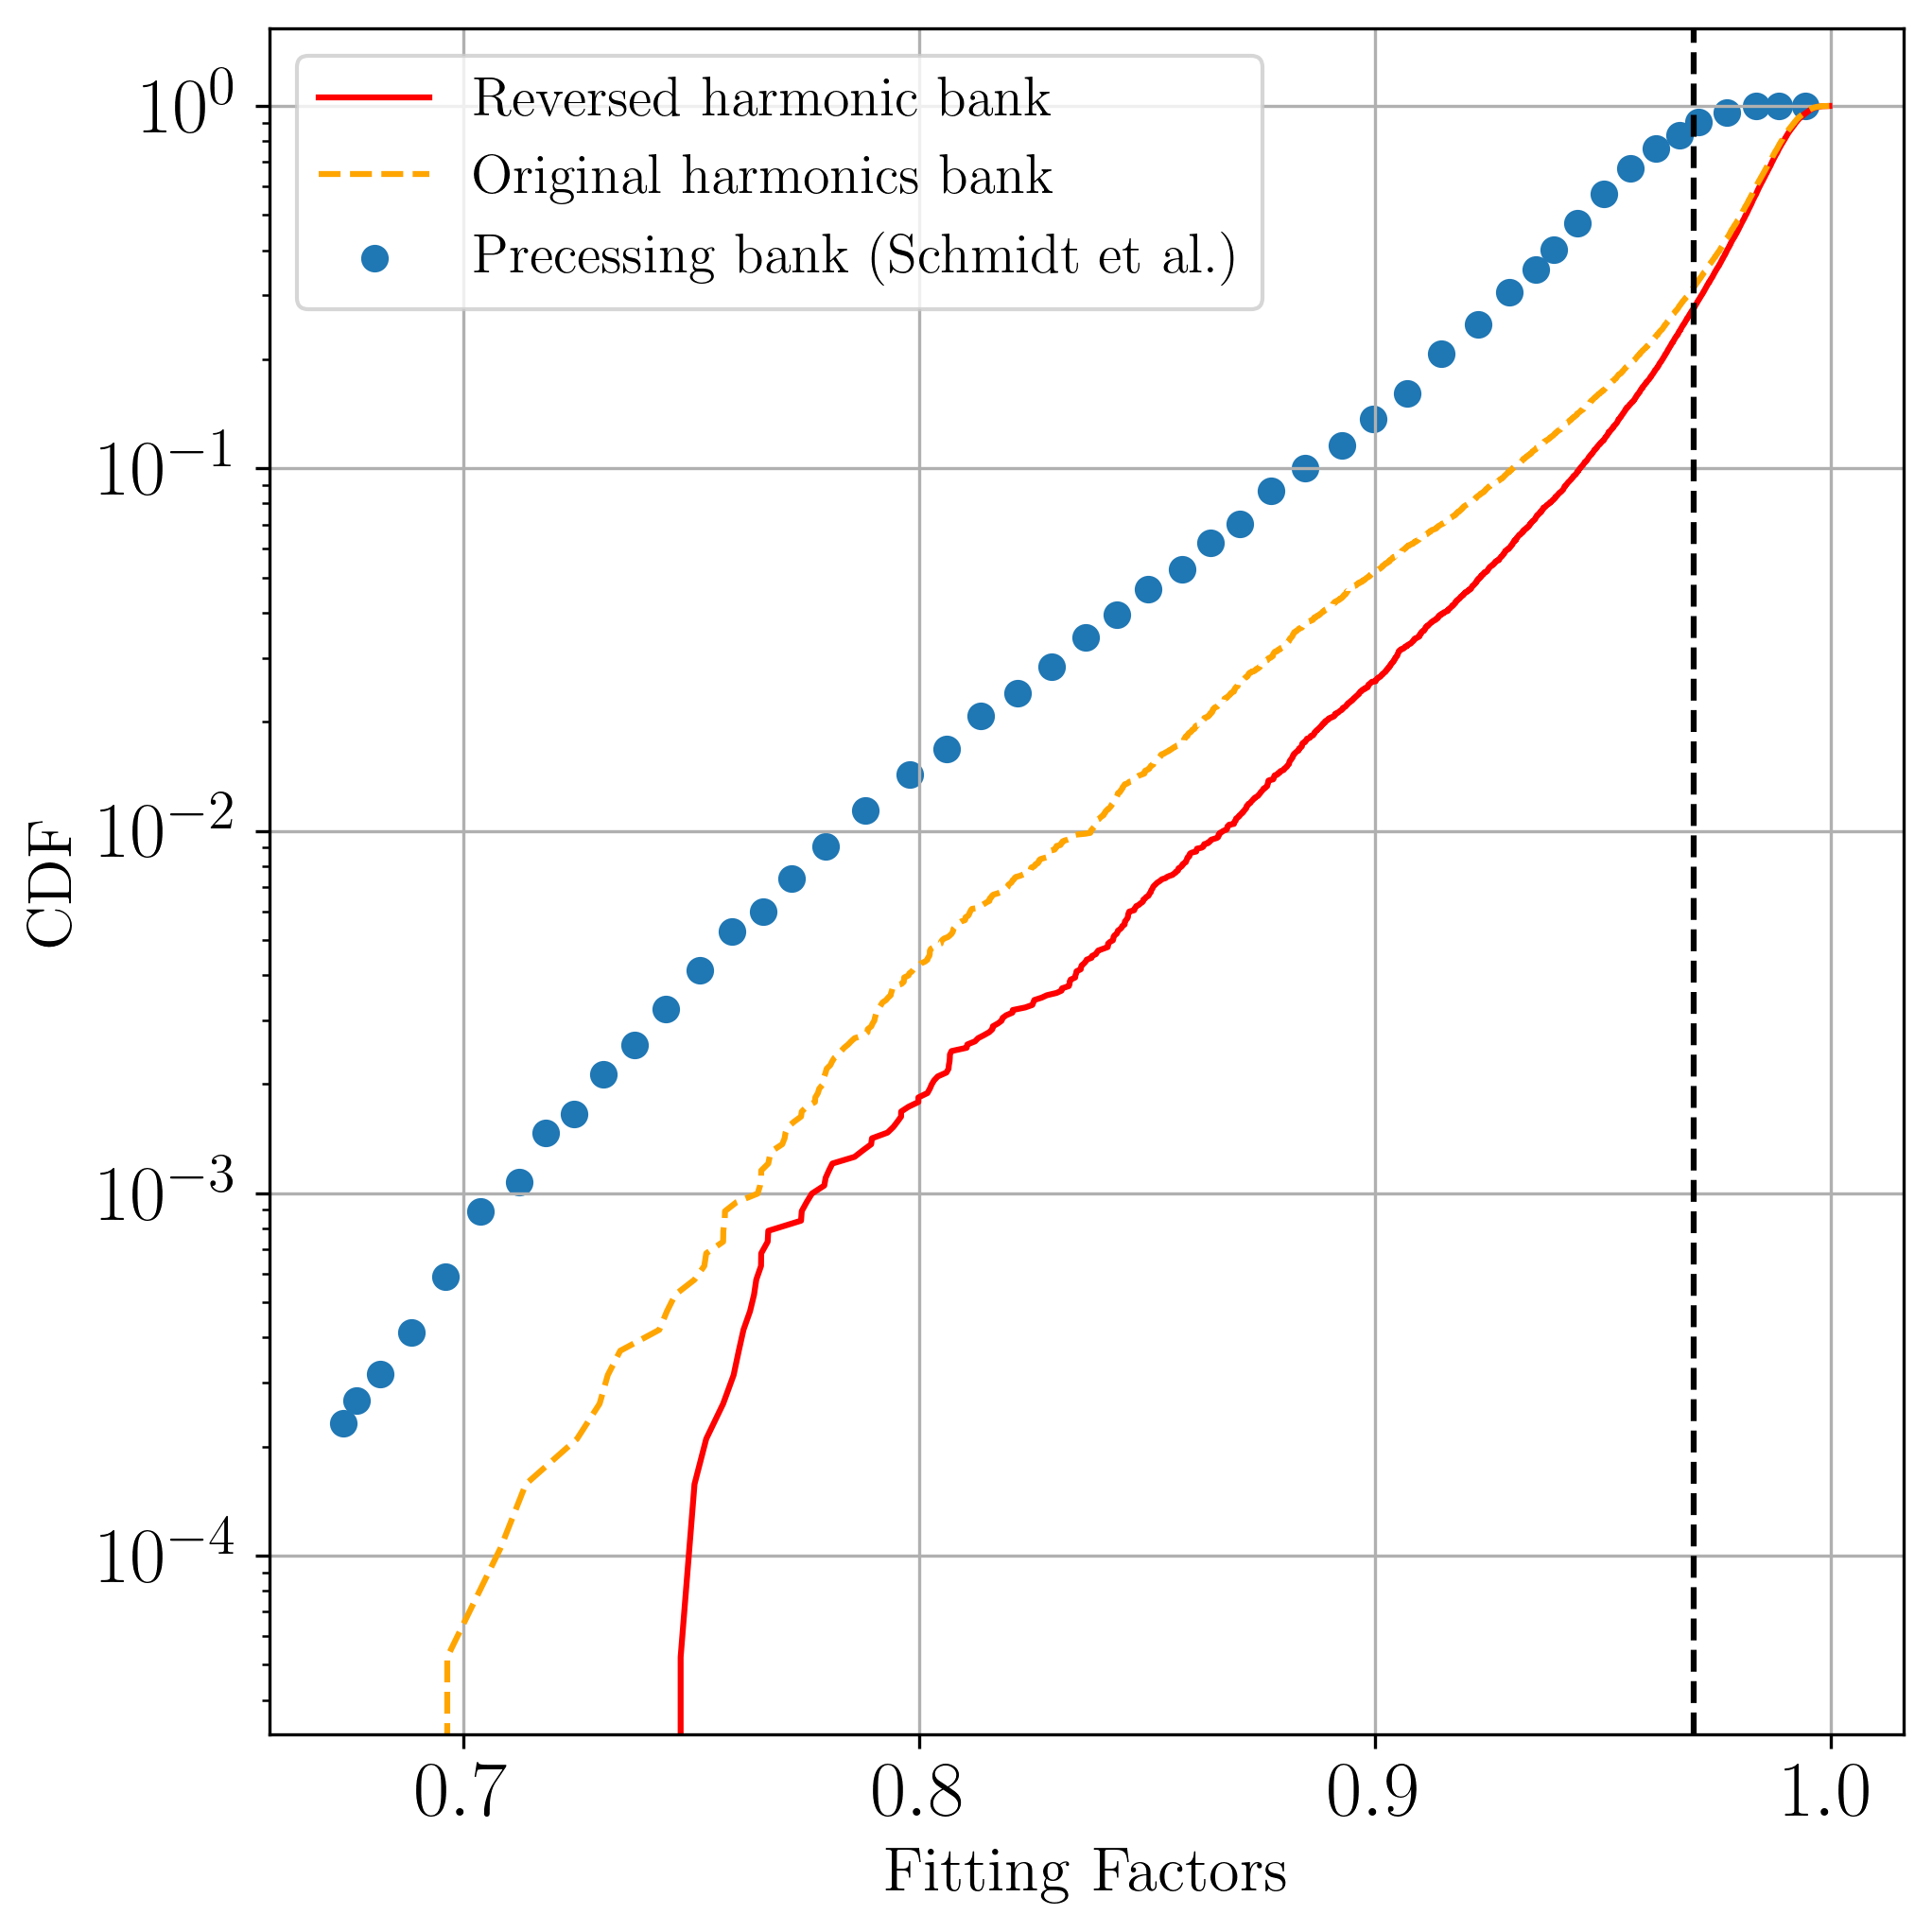

In [7]:
#FF = f['trig_params_3/match'][:]
#X = np.sort(FF)
#Y = np.array(range(len(FF)))/float(len(FF))
#plt.yscale('log')
#plt.plot(X,Y, label='Our bank ( mismatch = 0.9 )', color='green')

FF_high = highmatch['trig_params_3/match'][:]
X_high = np.sort(FF_high)
Y_high = np.array(range(len(FF_high)))/float(len(FF_high))
plt.yscale('log')
plt.plot(X_high,Y_high, label='Reversed harmonic bank', color='red')

FF_shave = shaved_match['trig_params_3/match'][:]
X_shave = np.sort(FF_shave)
Y_shave = np.array(range(len(FF_shave)))/float(len(FF_shave))
plt.yscale('log')
plt.plot(X_shave,Y_shave, label='Original harmonics bank', linestyle='--', color='orange')

df = np.loadtxt('/home/rahul.dhurkunde/searches/BBH-precession/banksim/P-P-GSTLal.txt', delimiter=',')
interp_FF = interp1d(df[:,0], df[:,1], fill_value='extrapolate')
plt.scatter(df[:,0], df[:,1], label='Precessing bank (Schmidt et al.)')
plt.axvline(0.97, color='black', linestyle='--')
#plt.plot(X, interp_FF(X))

plt.grid()
plt.xlabel('Fitting Factors', fontsize=16)
plt.ylabel('CDF', fontsize=16)
plt.legend(fontsize=14)
plt.tick_params(labelsize=20)
#plt.title('Only up to 3 Harmonics', fontsize=15)
plt.tight_layout()
#plt.savefig('Figures/FF-comparison.png', dpi=600)

## Fitting-factor CDF (successively adding the harmonics) 

<function matplotlib.pyplot.show(close=None, block=None)>

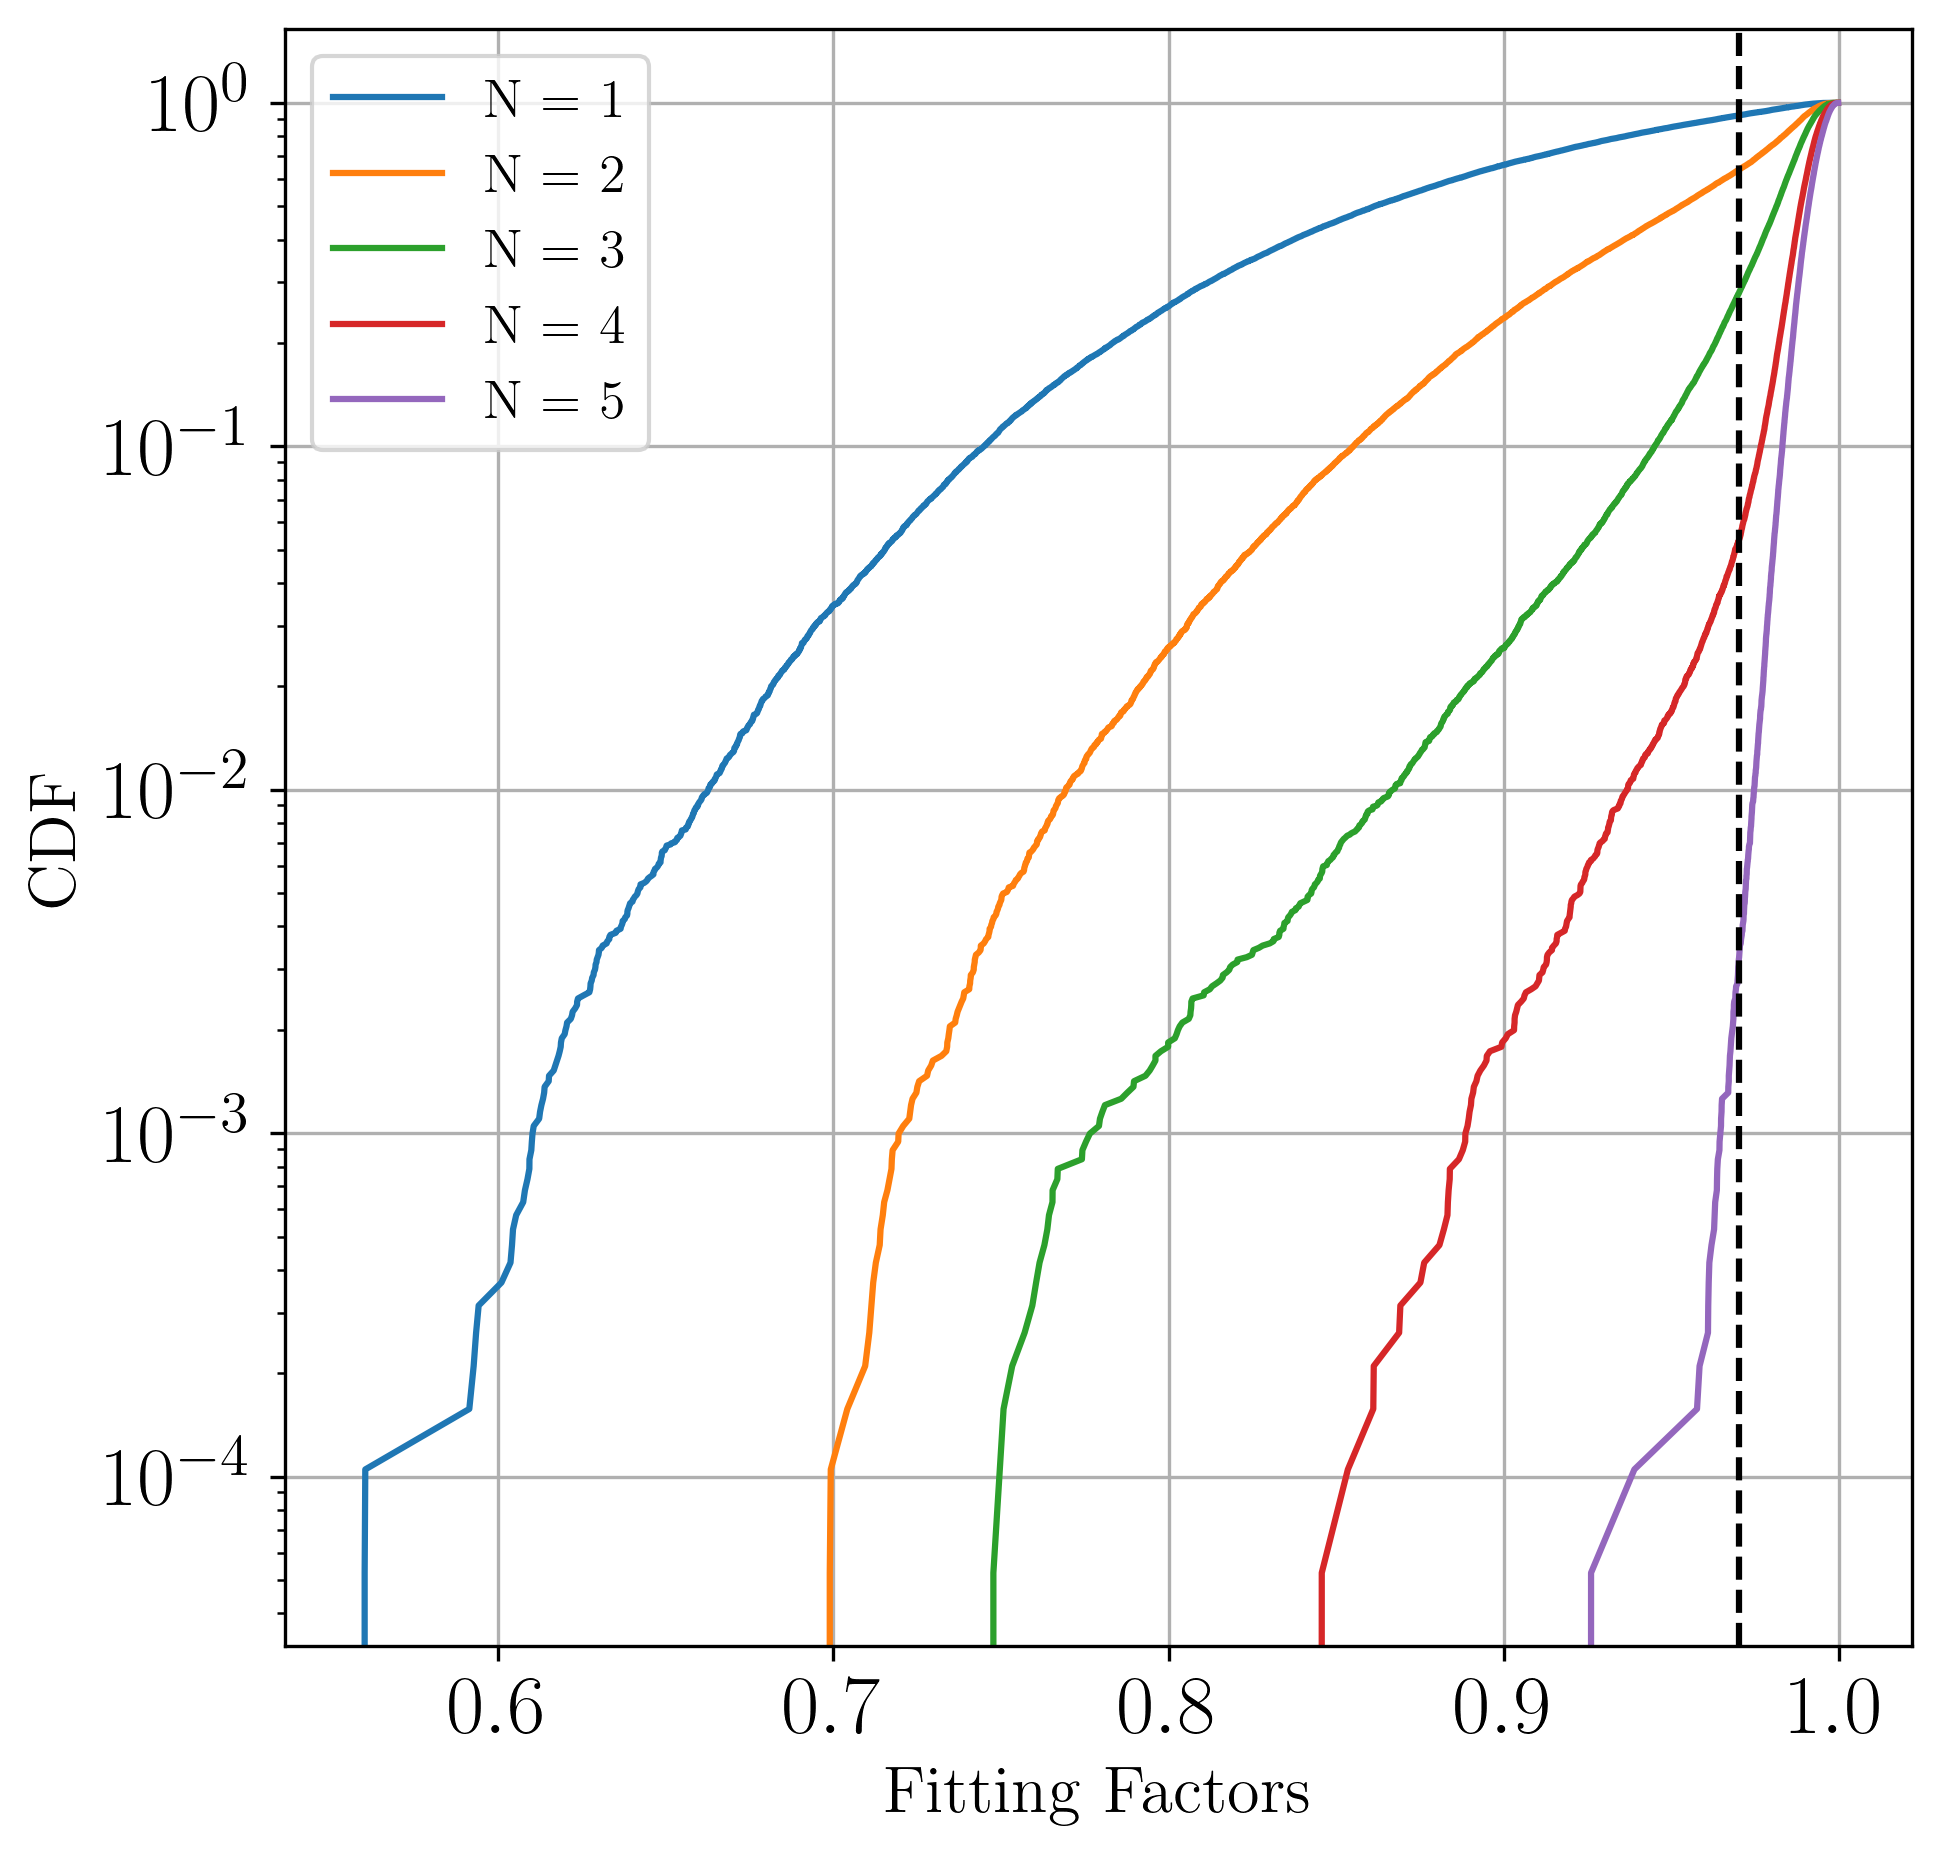

In [9]:
for i in range(1, 6, 1):
    j = highmatch
    key = 'trig_params_{}/match'.format(i)
    #print(key)
    FF_high = j[key][:]
    X_high = np.sort(FF_high)
    Y_high = np.array(range(len(FF_high)))/float(len(FF_high))
    label = 'N = {}'.format(i)
    plt.plot(X_high,Y_high, label=label)

plt.axvline(0.97, color='black', linestyle='--')
plt.xlabel('Fitting Factors', fontsize=16)
plt.ylabel('CDF', fontsize=16)
plt.legend(fontsize=14)
plt.tick_params(labelsize=20)
plt.yscale('log')
plt.legend(loc=0)
plt.grid()
plt.legend()
#plt.title('FF for injections (with same bank prior) against a bank with MM=0.97', fontsize=14)
#plt.savefig('Figures/FF-nharms.png', dpi=600)
plt.show

## Distribution of Ncomps

In [10]:
bank1 = h5py.File('/home/rahul.dhurkunde/searches/BBH-precession/Bank/xp_with_flags_nharms/og_harmonics/prec-xp-flag-og.h5')
bank2 = h5py.File('/home/rahul.dhurkunde/searches/BBH-precession/Bank/prec-full-bank.h5')

ncomp1 = bank1['num_comps'][:]
ncomp2 = bank2['num_comps'][:]

# Count the occurrences of each integer for both arrays
unique1, counts1 = np.unique(ncomp1, return_counts=True)
unique2, counts2 = np.unique(ncomp2, return_counts=True)

In [12]:
a = np.loadtxt('/home/rahul.dhurkunde/searches/BBH-precession/Bank/additional_params/prec-bank.txt')
ids = a[:,0]
mtotal = a[:, 1]
q = a[:, 2]
bs = a[:, 3]
chip = a[:, 4]

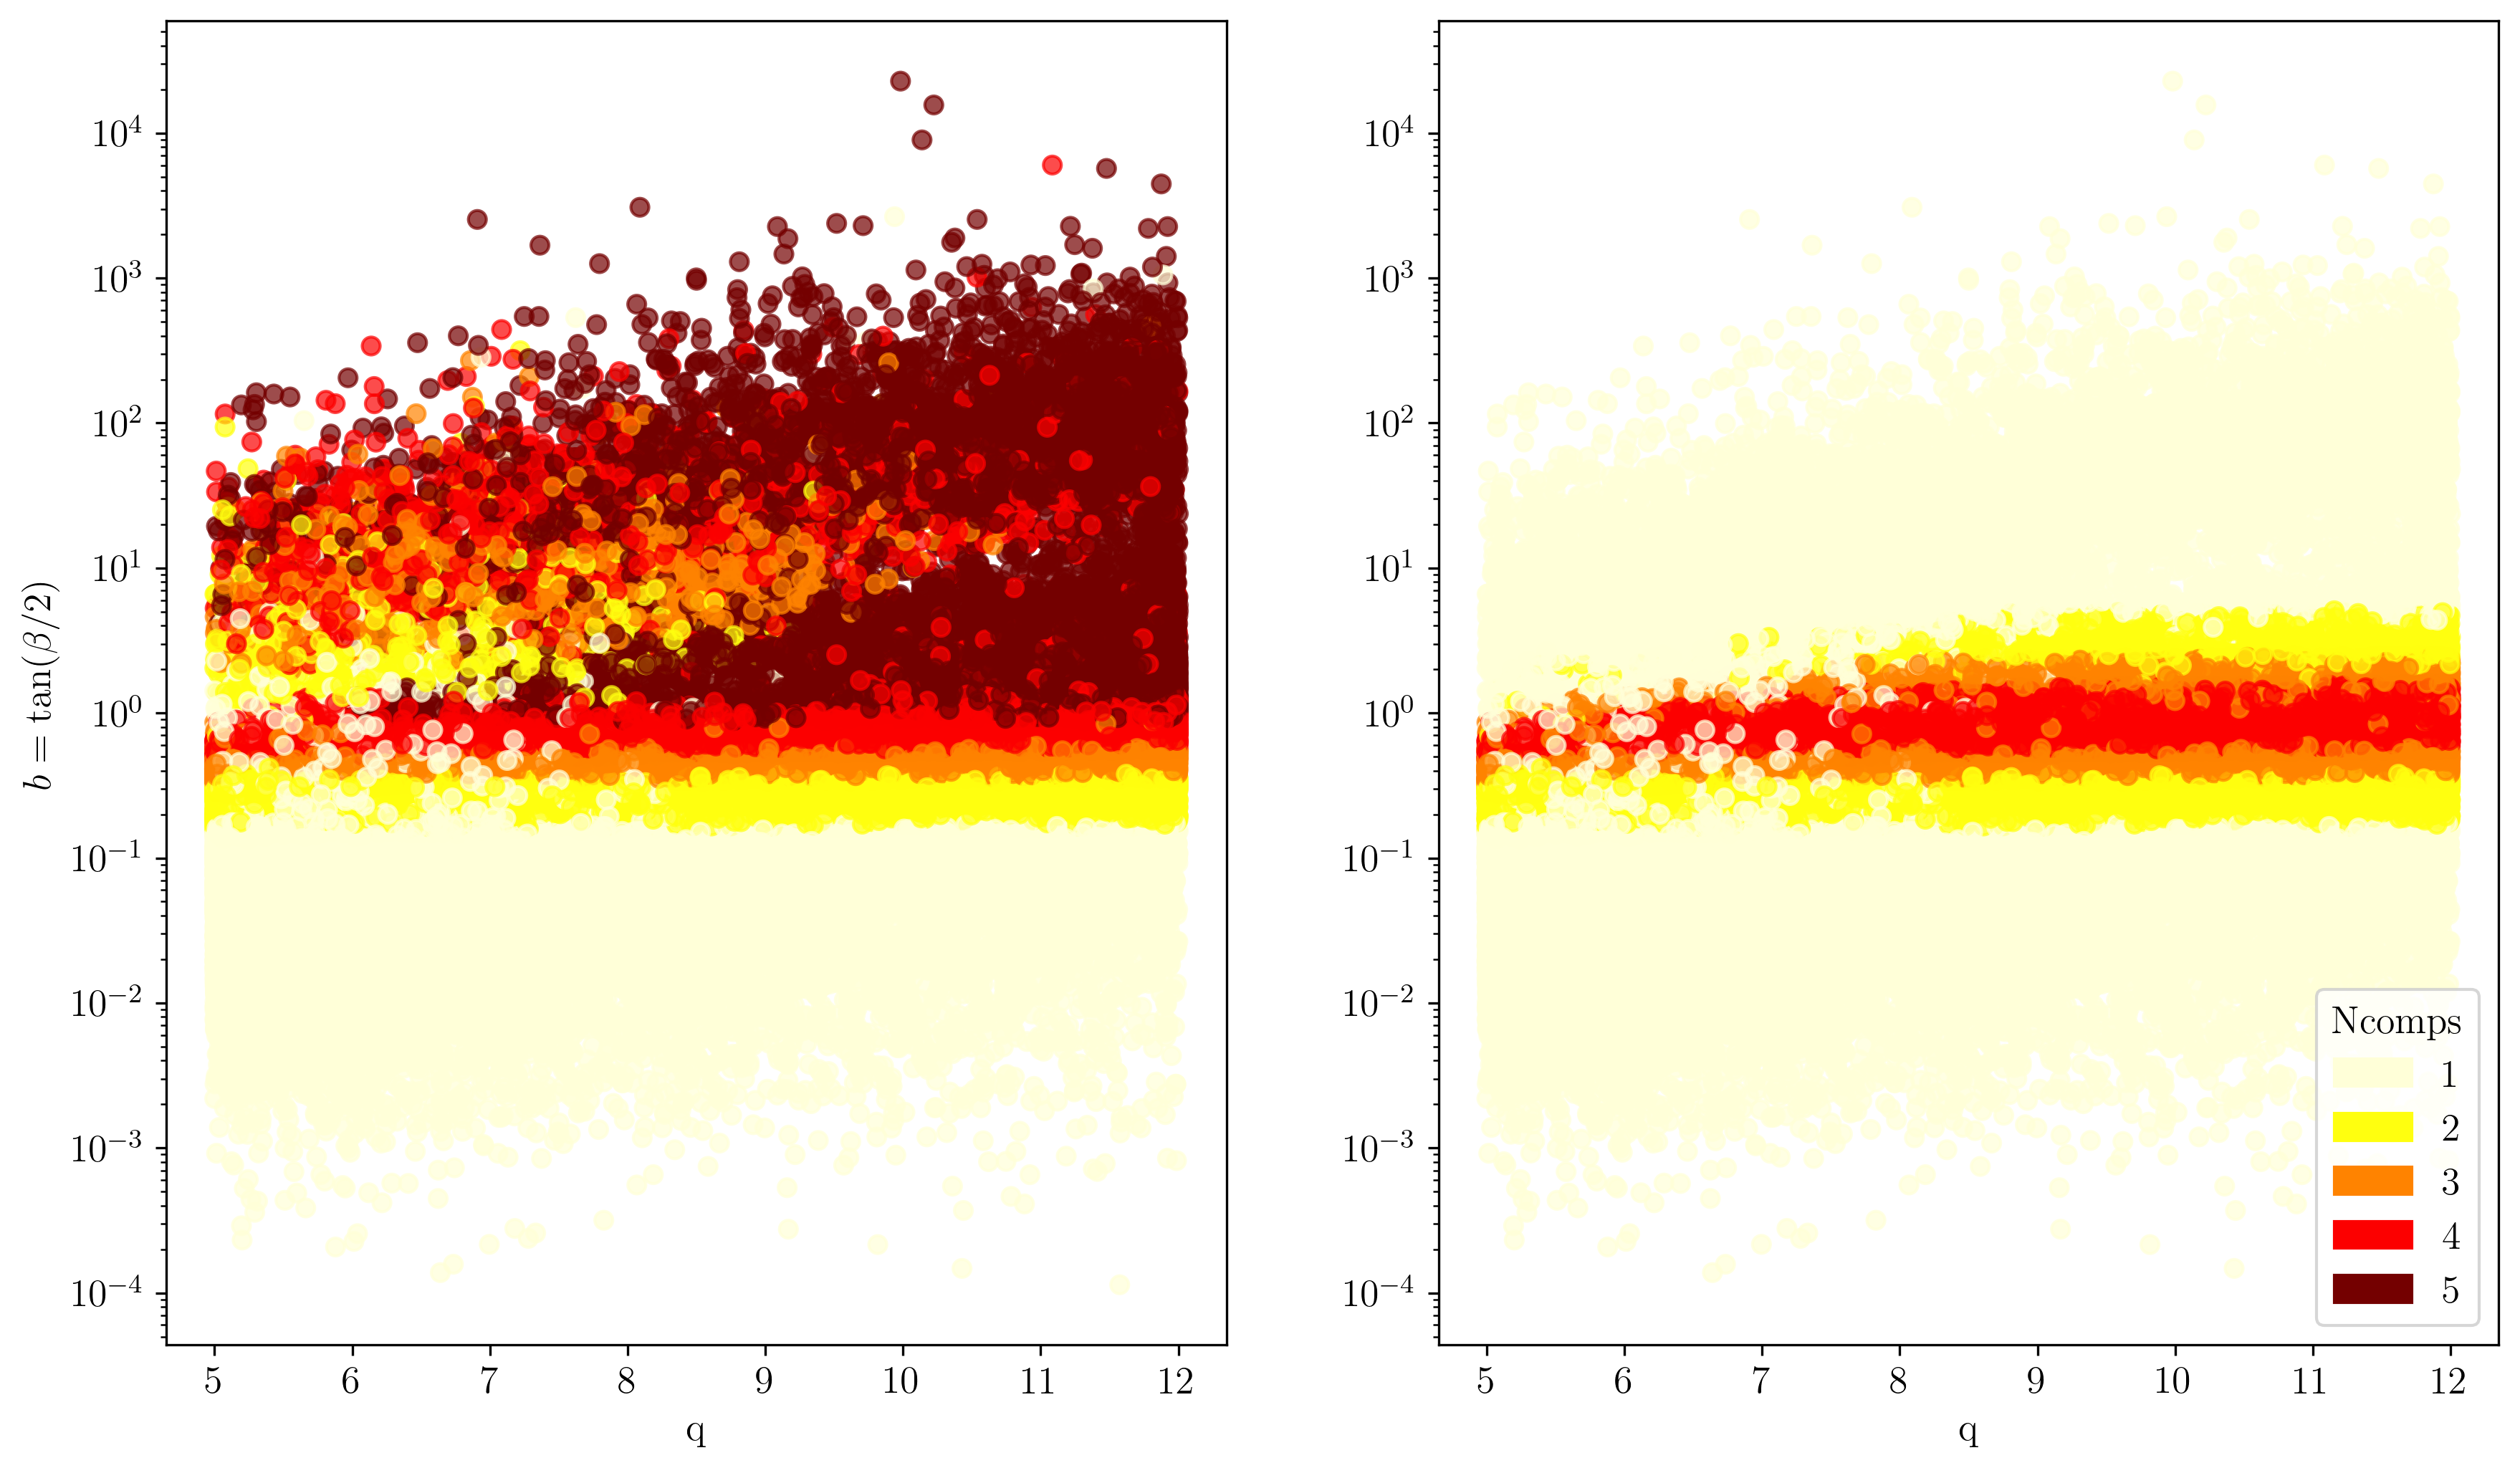

In [13]:
colormap = plt.colormaps['hot_r']  # Get the continuous colormap
colors1 = [colormap((i+0.2)/5.0) for i in range(len(unique1))]

# Extract colors from the first pie chart into a dictionary
color_dict = {label: color for label, color in zip(unique1, colors1)}

switch_ids = range(len(ncomp2))

fig, axs = plt.subplots(1,2, figsize=(14, 8))

# Map ncomp1 values to colors using the color dictionary
marker_colors = [color_dict[value] for value in ncomp1[switch_ids]]
axs[0].scatter(q[switch_ids], bs[switch_ids], c=marker_colors,alpha=0.7)
axs[0].set_yscale('log')
axs[0].set_xlabel('q')
axs[0].set_ylabel('$b=\\tan(\\beta/2)$')

colors_2 = [color_dict[value] for value in ncomp2[switch_ids]]
axs[1].scatter(q[switch_ids], bs[switch_ids], c=colors_2,alpha=0.7)
axs[1].set_yscale('log')
axs[1].set_xlabel('q')
#axs[1].set_title('IMRPhenomXP \n with reverse harmonics')
legend_handles = [
    mpatches.Patch(color=color, label=key) for key, color in color_dict.items()
]

# Add the legend
plt.legend(handles=legend_handles, title="Ncomps", loc='lower right')
#plt.savefig('Figures/Ncomp-comparison.png', dpi=600, bbox_inches='tight')

## Number Harmonics Pie-chart

5 colors


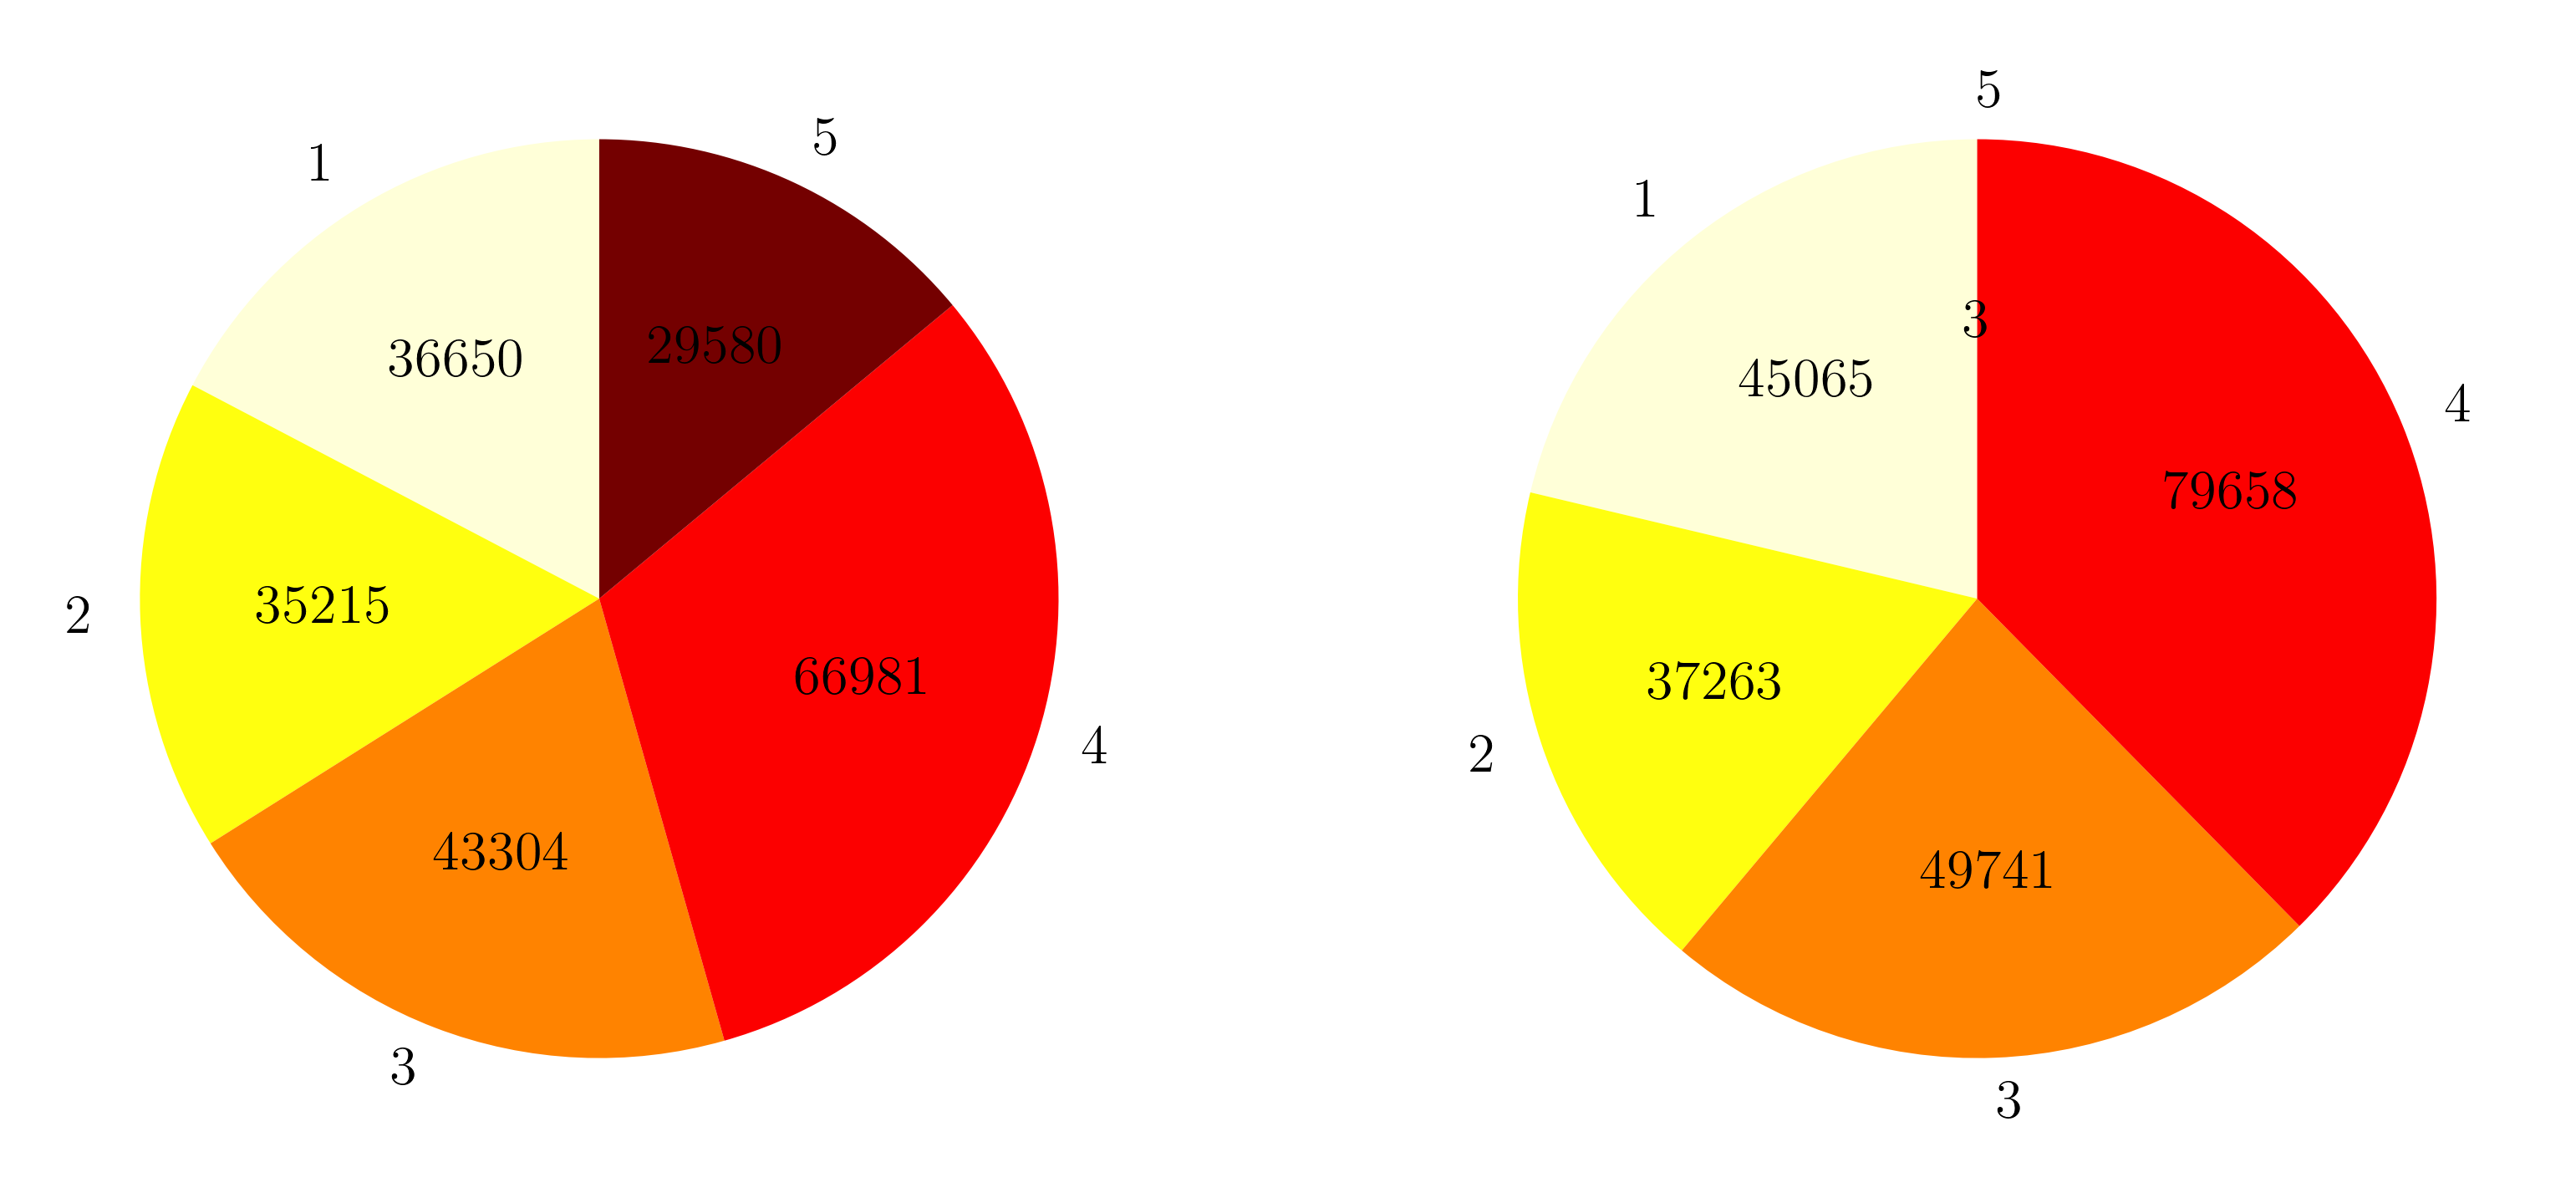

In [14]:
# Define a function to display absolute numbers
def absolute_number(pct, all_values):
    total = sum(all_values)
    absolute = int(round(pct * total / 100.0))
    return f"{absolute}"

# Create the subplots for pie charts
fig, axs = plt.subplots(1, 2, figsize=(13, 6))

colormap = plt.colormaps['hot_r']  # Get the continuous colormap
# Assign colors from the colormap
colors1 = [colormap((i+0.2)/5.0) for i in range(len(unique1))]
print(len(colors1), 'colors')

# First pie chart
axs[0].pie(
    counts1, 
    labels=unique1, 
    autopct=lambda pct: absolute_number(pct, counts1), 
    startangle=90, 
    textprops={'fontsize': 16},
    colors=colors1
)

# Second pie chart
axs[1].pie(
    counts2, 
    labels=unique2, 
    autopct=lambda pct: absolute_number(pct, counts2), 
    startangle=90, 
    textprops={'fontsize': 16},
    colors=colors1
)

#plt.tight_layout()
legend_handles = [
    mpatches.Patch(color=color, label=key) for key, color in color_dict.items()
]


plt.show()